# Data preparation and exploration

This notebook validates the quarterly NPL, Brent and USD/KZT dataset for 2010Q1–2026Q2 and explores the three series with historical event markers. It does not fit models or choose transformations and lags.

Run from `notebooks/`. The input CSV remains unchanged; figures are saved in `reports/figures/`.

## Data import

In [1]:
from pathlib import Path

import matplotlib.dates as mdates
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import display

pd.set_option("display.max_columns", 20)
pd.set_option("display.float_format", lambda value: f"{value:,.2f}")
sns.set_theme(style="whitegrid", context="notebook")

DATA_PATH = Path("../data/raw/kazakhstan_npl_oil_fx_quarterly.csv")
FIGURE_DIRECTORY = Path("../reports/figures")
EXPECTED_COLUMNS = ["quarter", "npl", "brent", "usdkzt"]
VALUE_COLUMNS = EXPECTED_COLUMNS[1:]
FIRST_QUARTER = "2010Q1"
LAST_QUARTER = "2026Q2"
TEST_START_QUARTER = "2022Q1"
SERIES_LABELS = {
    "npl": "NPL 90+",
    "brent": "Brent",
    "usdkzt": "USD/KZT",
}
SERIES_COLORS = {
    "npl": "#E45756",
    "brent": "#4C78A8",
    "usdkzt": "#59A14F",
}

assert DATA_PATH.exists(), f"Missing input file: {DATA_PATH}"

In [2]:
# load the source snapshot, stored to two decimals
quarterly_data = pd.read_csv(DATA_PATH)
quarterly_data.head()

Out[1]: 
  quarter   npl  brent  usdkzt
0  2010Q1 24.96  76.67  147.70
1  2010Q2 25.25  78.85  146.81
2  2010Q3 25.83  76.68  147.41
3  2010Q4 23.75  87.03  147.49
4  2011Q1 25.27 105.37  146.42


In [3]:
quarterly_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 66 entries, 0 to 65
Data columns (total 4 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   quarter  66 non-null     object 
 1   npl      66 non-null     float64
 2   brent    66 non-null     float64
 3   usdkzt   66 non-null     float64
dtypes: float64(3), object(1)
memory usage: 2.2+ KB


## Variable definitions

| Variable | Definition | Timing |
| --- | --- | --- |
| `npl` | Sector-wide share of loans overdue more than 90 days, in percent | Quarter-end stock |
| `brent` | Nominal Brent price, in USD per barrel | Quarterly average |
| `usdkzt` | Official exchange rate, in KZT per USD; an increase means tenge depreciation | Quarterly average |

NPL is an outstanding stock, not loans newly entering default during a 90-day window. A loan may remain in this stock for several quarters. Reports dated 1 April, 1 July, 1 October and 1 January describe the preceding quarter-end; quarter-start oil labels identify the quarter they begin.

Sources: [NBK banking-sector archive](https://nationalbank.kz/en/news/banks-performance/rubrics/1943), supplied NBK/ARRFR reports, [FRED Brent](https://fred.stlouisfed.org/series/POILBREUSDM) and [NBK exchange rates](https://nationalbank.kz/en/news/oficialnye-kursy). All numeric inputs are stored to two decimals. NPL uses the sector-wide 90+ share and January closing-adjusted sheets where available. Extraction details and averaging conventions are recorded in [data_sources.md](../docs/data_sources.md).

## Data quality checks

In [4]:
# verify the schema before interpreting individual columns
assert quarterly_data.columns.tolist() == EXPECTED_COLUMNS
assert quarterly_data["quarter"].str.fullmatch(r"\d{4}Q[1-4]").all()
assert quarterly_data[VALUE_COLUMNS].select_dtypes(include=np.number).shape[1] == 3

quarter_index = pd.PeriodIndex(quarterly_data["quarter"], freq="Q-DEC")
expected_quarters = pd.period_range(FIRST_QUARTER, LAST_QUARTER, freq="Q-DEC")
missing_quarters = expected_quarters.difference(quarter_index)

quality_summary = pd.Series({
    "rows": len(quarterly_data),
    "columns": quarterly_data.shape[1],
    "first quarter": quarterly_data["quarter"].iloc[0],
    "last quarter": quarterly_data["quarter"].iloc[-1],
    "missing values": int(quarterly_data.isna().sum().sum()),
    "infinite numeric values": int(np.isinf(quarterly_data[VALUE_COLUMNS]).sum().sum()),
    "duplicate quarter labels": int(quarterly_data["quarter"].duplicated().sum()),
    "surplus exact duplicate rows": int(quarterly_data.duplicated().sum()),
    "missing calendar quarters": len(missing_quarters),
    "quarters in chronological order": quarter_index.is_monotonic_increasing,
}, name="value").to_frame()
display(quality_summary)

assert len(quarterly_data) == len(expected_quarters) == 66
assert quarter_index.equals(expected_quarters)
assert not quarterly_data["quarter"].duplicated().any()
assert not quarterly_data.duplicated().any()
assert quarterly_data.isna().sum().sum() == 0
assert np.isfinite(quarterly_data[VALUE_COLUMNS].to_numpy()).all()
assert quarterly_data["npl"].between(0, 100).all()
assert quarterly_data[["brent", "usdkzt"]].gt(0).all().all()

,value
rows,66
columns,4
first quarter,2010Q1
last quarter,2026Q2
missing values,0
infinite numeric values,0
duplicate quarter labels,0
surplus exact duplicate rows,0
missing calendar quarters,0
quarters in chronological order,True


In [5]:
# inspect each column's type and range
column_profile = pd.DataFrame({
    "dtype": quarterly_data[VALUE_COLUMNS].dtypes.astype(str),
    "missing": quarterly_data[VALUE_COLUMNS].isna().sum(),
    "unique values": quarterly_data[VALUE_COLUMNS].nunique(),
    "minimum": quarterly_data[VALUE_COLUMNS].min(),
    "maximum": quarterly_data[VALUE_COLUMNS].max(),
})
column_profile

Out[1]: 
          dtype  missing  unique values  minimum  maximum
npl     float64        0             65     2.89    32.89
brent   float64        0             66    33.38   118.43
usdkzt  float64        0             65   145.59   536.05


## Cleaning

The input is complete, numeric and chronological, with one row per quarter. No imputation, interpolation, duplicate removal or observation deletion is needed. Genuine jumps are retained.

Quarter-end dates are added to a working copy for plotting only. Brent and USD/KZT remain quarterly averages; connecting the observations does not show daily movements.

In [6]:
# create a working copy and a quarter-end date for graph alignment
analysis_data = quarterly_data.copy()
analysis_data.insert(
    1, "quarter_end", quarter_index.to_timestamp(how="end").normalize()
)
pd.testing.assert_frame_equal(analysis_data[EXPECTED_COLUMNS], quarterly_data)
analysis_data.tail()

Out[1]: 
   quarter quarter_end  npl  brent  usdkzt
61  2025Q2  2025-06-30 3.37  66.96  513.77
62  2025Q3  2025-09-30 3.52  68.14  536.05
63  2025Q4  2025-12-31 3.63  63.16  524.76
64  2026Q1  2026-03-31 3.97  77.80  497.73
65  2026Q2  2026-06-30 4.12  97.05  476.00


## Exploration

### Descriptive statistics

In [7]:
# summarize the full history for description, not for model selection
summary_statistics = analysis_data[VALUE_COLUMNS].describe().T
display(summary_statistics)

,count,mean,std,min,25%,50%,75%,max
npl,66.00,13.34,10.80,2.89,3.71,8.56,25.18,32.89
brent,66.00,78.05,23.05,33.38,62.23,76.62,97.73,118.43
usdkzt,66.00,326.10,133.50,145.59,173.00,348.76,446.40,536.05


### Chronological split

Training ends in 2021Q4; the final test begins in 2022Q1. This table records the boundary without fitting a model.

In [8]:
# record the required chronological split without fitting or tuning anything
test_mask = quarter_index >= pd.Period(TEST_START_QUARTER, freq="Q-DEC")
split_summary = pd.DataFrame([
    {
        "sample": sample_name,
        "first quarter": analysis_data.loc[mask, "quarter"].iloc[0],
        "last quarter": analysis_data.loc[mask, "quarter"].iloc[-1],
        "observations before lags": int(mask.sum()),
    }
    for sample_name, mask in [
        ("training", ~test_mask), ("final test", test_mask)
    ]
]).set_index("sample")
display(split_summary)

assert (~test_mask).sum() == 48
assert test_mask.sum() == 18

,first quarter,last quarter,observations before lags
sample,,,
training,2010Q1,2021Q4,48
final test,2022Q1,2026Q2,18


Full-history summaries and charts are descriptive. Model-design diagnostics and selection use only pre-2022 observations.

### Large NPL movements

In [9]:
# identify large stock changes for review, not automatic exclusion
npl_movements = analysis_data[["quarter", "npl"]].copy()
npl_movements["previous_npl_pct"] = npl_movements["npl"].shift(1)
npl_movements["change_pp"] = (
    npl_movements["npl"] - npl_movements["previous_npl_pct"]
)
largest_movements = (
    npl_movements.dropna()
    .assign(absolute_change=lambda data: data["change_pp"].abs())
    .sort_values("absolute_change", ascending=False)
    .head(5)
    .drop(columns="absolute_change")
)
display(largest_movements)

restructuring_rows = analysis_data["quarter"].isin(["2015Q1", "2015Q2"])
display(analysis_data.loc[restructuring_rows, EXPECTED_COLUMNS])

,quarter,npl,previous_npl_pct,change_pp
21,2015Q2,9.98,23.42,-13.44
19,2014Q4,23.55,29.72,-6.17
31,2017Q4,9.31,12.75,-3.44
6,2011Q3,29.46,26.27,3.19
29,2017Q2,10.71,7.68,3.03


,quarter,npl,brent,usdkzt
20,2015Q1,23.42,54.57,184.64
21,2015Q2,9.98,62.55,185.86


NPL falls from **23.42% to 9.98% in 2015Q2**, a **13.44 percentage-point** decline. The July 2015 report links the loan-portfolio reduction to Kazkommertsbank/BTA transfers and BTA's banking-sector exit, but does not quantify each factor's contribution to the NPL share. Retain the observation as a potential structural break rather than attributing it solely to oil or FX. See the [2015 source notes](../docs/data_sources.md#2015-quarterly-pdf-reports).

## Historical events

Markers provide context, not confirmed statistical breaks or causal effects. The oil-price shading is an illustrative 2014H2–2015 window. The banking marker uses 2015Q2 quarter-end, not an exact transaction date.

| Event | Marker or window | Source |
| --- | --- | --- |
| Oil-price decline | July 2014–December 2015 | [EIA: 2014](https://www.eia.gov/todayinenergy/detail.php?id=19451), [EIA: 2015](https://www.eia.gov/todayinenergy/detail.php?id=24432) |
| Banking restructuring / NPL decline | 2015Q2 | [Banking report notes](../docs/data_sources.md#2015-quarterly-pdf-reports) |
| Tenge moves to a floating exchange rate | 20 August 2015 | [NBK annual report](https://nationalbank.kz/file/download/1021) |
| WHO characterizes COVID-19 as a pandemic | 11 March 2020 | [WHO](https://www.who.int/europe/emergencies/situations/covid-19) |
| Russia's full-scale invasion of Ukraine | 24 February 2022 | [European Council](https://www.consilium.europa.eu/en/press/press-releases/2022/02/24/european-council-conclusions-24-february-2022/) |

In [10]:
# keep event definitions in one place for both figures
OIL_DECLINE_START = pd.Timestamp("2014-07-01")
OIL_DECLINE_END = pd.Timestamp("2015-12-31")
OIL_WINDOW_COLOR = "#E9B96E"

events = pd.DataFrame([
    {
        "date": "2015-06-30", "event": "Bank restructuring / NPL drop",
        "label": "Bank restructuring\n2015Q2", "lane": 0.76,
        "color": "#8C564B",
    },
    {
        "date": "2015-08-20", "event": "Tenge float",
        "label": "Tenge float\n20 Aug 2015", "lane": 0.24,
        "color": "#7B61A8",
    },
    {
        "date": "2020-03-11", "event": "COVID-19 pandemic",
        "label": "COVID-19\n11 Mar 2020", "lane": 0.76,
        "color": "#676767",
    },
    {
        "date": "2022-02-24", "event": "Full-scale invasion of Ukraine",
        "label": "Full-scale invasion\n24 Feb 2022", "lane": 0.76,
        "color": "#B74D4D",
    },
])
events["date"] = pd.to_datetime(events["date"])
display(events[["date", "event"]])

,date,event
0,2015-06-30,Bank restructuring / NPL drop
1,2015-08-20,Tenge float
2,2020-03-11,COVID-19 pandemic
3,2022-02-24,Full-scale invasion of Ukraine


## Time-series plots

In [11]:
def add_event_markers(axis):
    # shade the oil-price decline window and mark dated events
    axis.axvspan(
        OIL_DECLINE_START, OIL_DECLINE_END,
        color=OIL_WINDOW_COLOR, alpha=0.16, zorder=0,
    )
    for event in events.itertuples(index=False):
        axis.axvline(
            event.date, color=event.color, linestyle="--",
            linewidth=1, alpha=0.65, zorder=1,
        )


def add_event_timeline(axis):
    # use a separate label strip to avoid covering the three series
    axis.set_ylim(0, 1)
    axis.axvspan(
        OIL_DECLINE_START, OIL_DECLINE_END,
        color=OIL_WINDOW_COLOR, alpha=0.16,
    )
    axis.annotate(
        "Oil-price decline\n2014H2–2015",
        xy=(pd.Timestamp("2014-12-31"), 0.24),
        xytext=(-38, 0), textcoords="offset points",
        ha="right", va="center", fontsize=9, color="#805619",
    )
    for event in events.itertuples(index=False):
        axis.axvline(
            event.date, color=event.color, linestyle="--",
            linewidth=1, alpha=0.65,
        )
        axis.text(
            event.date + pd.Timedelta(days=45), event.lane,
            event.label, ha="left", va="center",
            fontsize=9, color=event.color,
        )
    axis.set_yticks([])
    axis.grid(False)
    for spine in ["top", "left", "right"]:
        axis.spines[spine].set_visible(False)
    axis.xaxis.set_major_locator(mdates.YearLocator(2))
    axis.xaxis.set_minor_locator(mdates.YearLocator())
    axis.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
    axis.tick_params(axis="x", which="minor", length=3)
    axis.set_xlim(
        analysis_data["quarter_end"].iloc[0] - pd.Timedelta(days=90),
        analysis_data["quarter_end"].iloc[-1] + pd.Timedelta(days=90),
    )
    axis.set_xlabel("Calendar quarter (observations placed at quarter-end)")

### Combined indexed chart

Different units make the raw series unsuitable for a shared vertical axis. For this chart only, each series is rebased to **2010Q1 = 100**:

`index = 100 × value / its 2010Q1 value`

An index of 150 means 50% above that series' starting value, not 150% NPL. Rebasing is for visualization, not model estimation; crossings and co-movement do not establish equal raw values or causality.

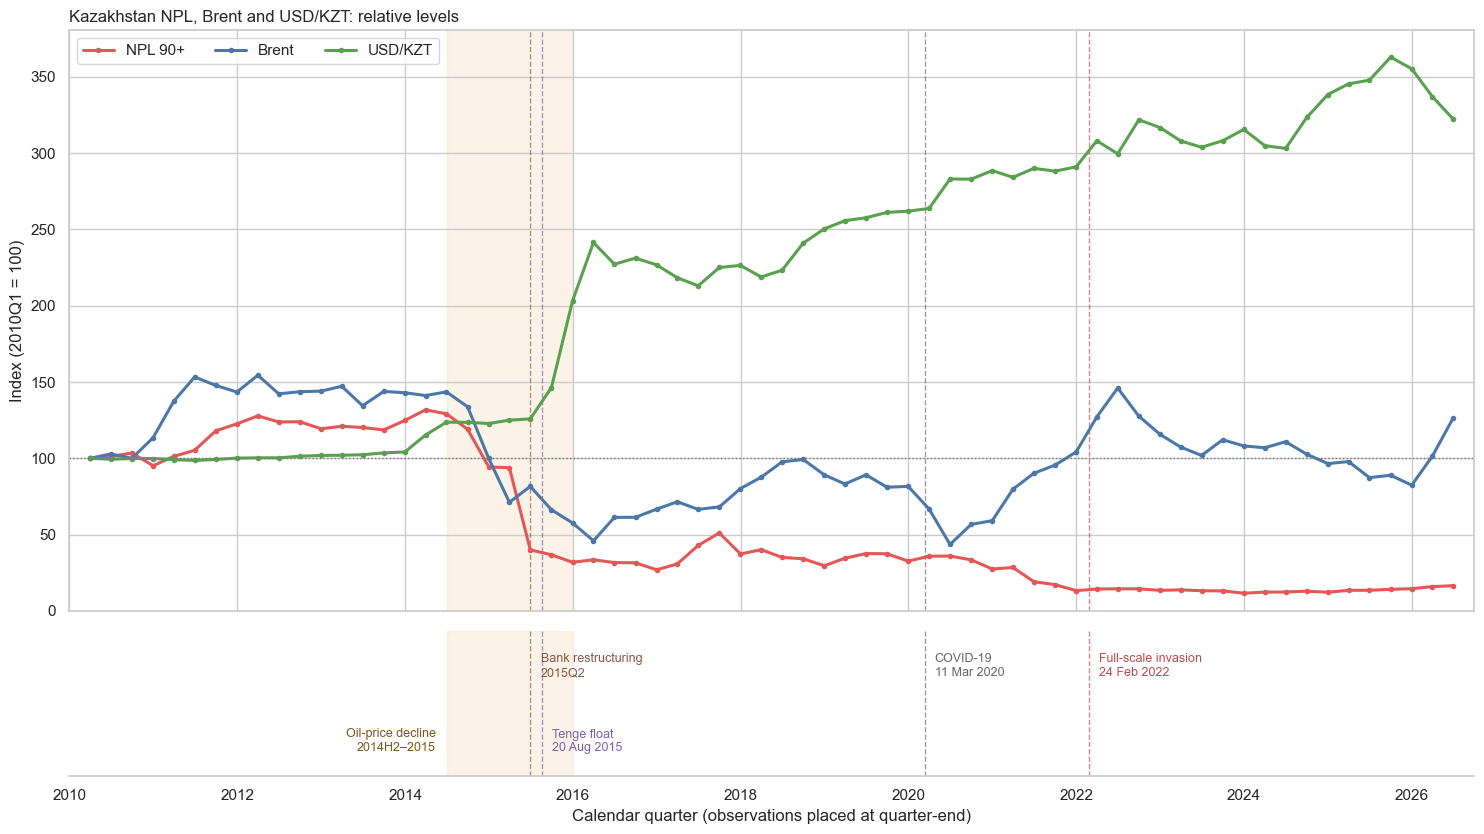

In [12]:
# rebase each series to the same starting level for the combined chart
base_values = analysis_data[VALUE_COLUMNS].iloc[0]
indexed_data = analysis_data[VALUE_COLUMNS].div(base_values).mul(100)
assert np.allclose(indexed_data.iloc[0].to_numpy(), 100)

figure, axes = plt.subplots(
    2, 1, figsize=(15, 8.5), sharex=True,
    gridspec_kw={"height_ratios": [5, 1.25]},
)
for column in VALUE_COLUMNS:
    axes[0].plot(
        analysis_data["quarter_end"], indexed_data[column],
        label=SERIES_LABELS[column], color=SERIES_COLORS[column],
        linewidth=2.2, marker="o", markersize=3,
    )

add_event_markers(axes[0])
axes[0].axhline(100, color="#777777", linestyle=":", linewidth=1)
axes[0].set_title(
    "Kazakhstan NPL, Brent and USD/KZT: relative levels", loc="left"
)
axes[0].set_ylabel("Index (2010Q1 = 100)")
axes[0].set_ylim(bottom=0)
axes[0].legend(loc="upper left", ncol=3, frameon=True)
axes[0].tick_params(axis="x", labelbottom=False)
add_event_timeline(axes[1])

figure.tight_layout(h_pad=0.7)
FIGURE_DIRECTORY.mkdir(parents=True, exist_ok=True)
COMBINED_FIGURE_PATH = FIGURE_DIRECTORY / "01_combined_indexed_series.png"
figure.savefig(COMBINED_FIGURE_PATH, dpi=180, bbox_inches="tight")
plt.show()
plt.close(figure)

### Original-unit charts

The separate panels show NPL in percent, Brent in USD per barrel and USD/KZT in KZT per USD, with the same dates and event markers.

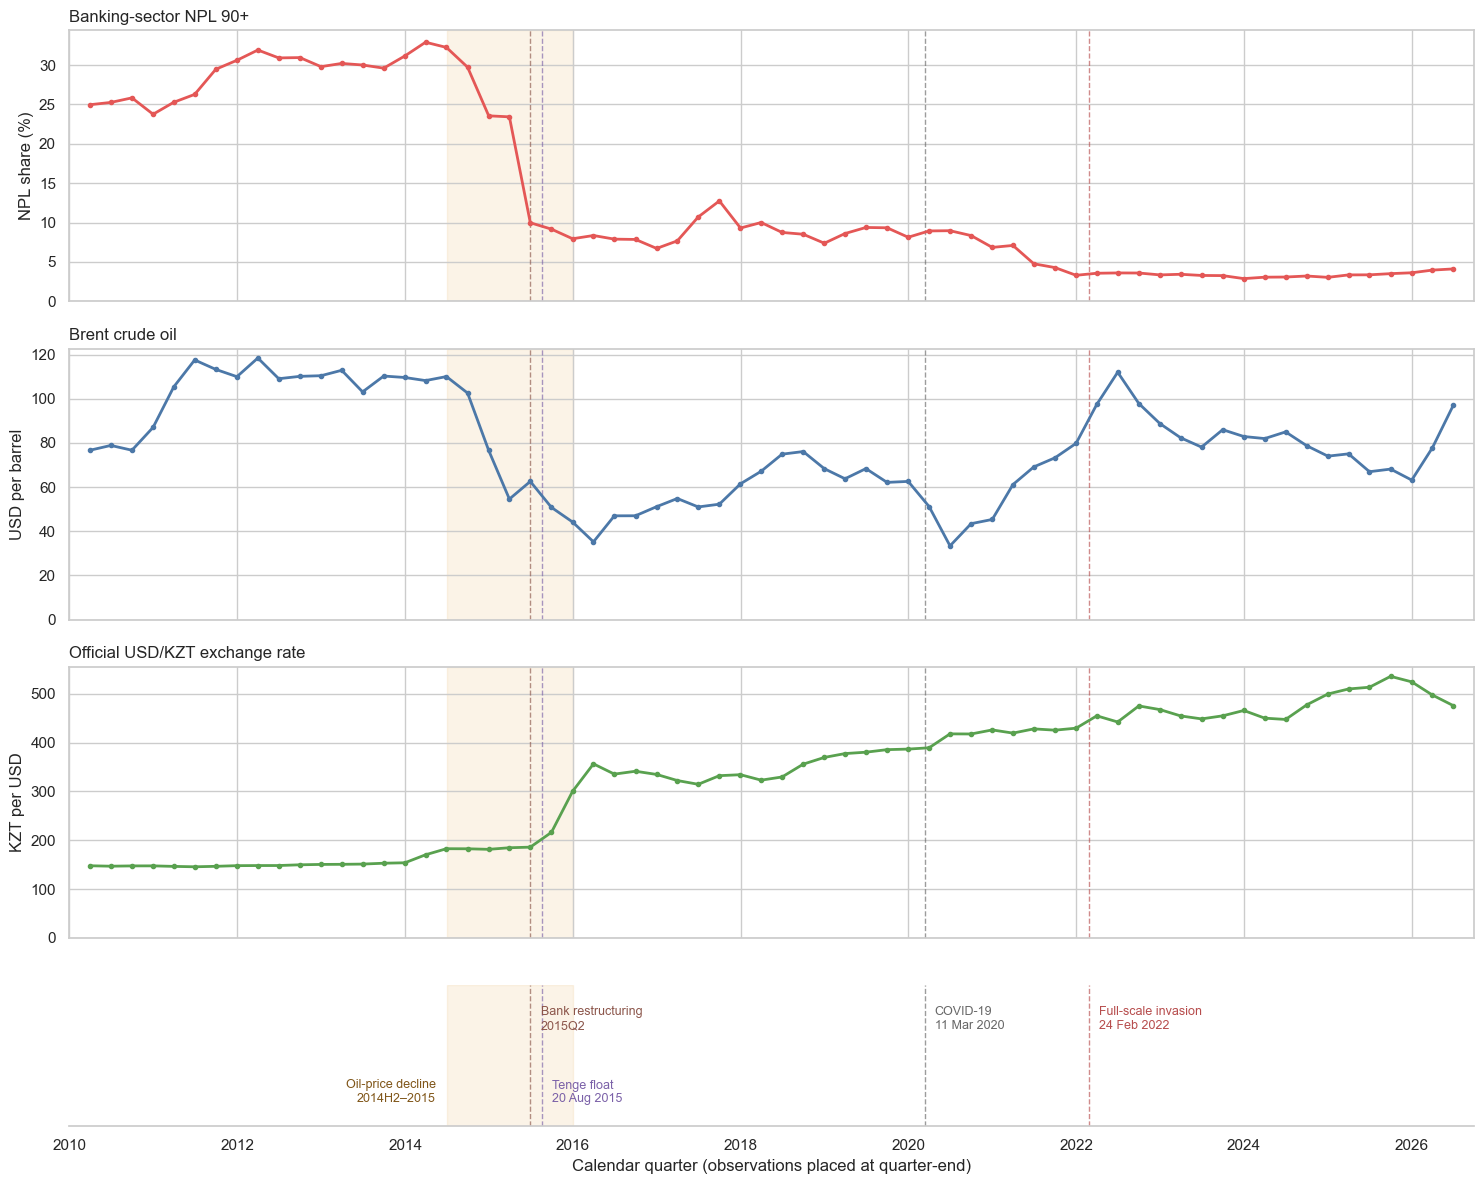

In [13]:
# show each series in its original units with a shared event timeline
figure, axes = plt.subplots(
    4, 1, figsize=(15, 12), sharex=True,
    gridspec_kw={"height_ratios": [2.4, 2.4, 2.4, 1.25]},
)
panel_settings = [
    ("npl", "Banking-sector NPL 90+", "NPL share (%)"),
    ("brent", "Brent crude oil", "USD per barrel"),
    ("usdkzt", "Official USD/KZT exchange rate", "KZT per USD"),
]
for axis, (column, title, unit) in zip(axes[:3], panel_settings):
    axis.plot(
        analysis_data["quarter_end"], analysis_data[column],
        color=SERIES_COLORS[column], linewidth=2,
        marker="o", markersize=3,
    )
    add_event_markers(axis)
    axis.set_title(title, loc="left", fontsize=12)
    axis.set_ylabel(unit)
    axis.set_ylim(bottom=0)
    axis.tick_params(axis="x", labelbottom=False)

add_event_timeline(axes[3])
figure.tight_layout(h_pad=1.1)
ORIGINAL_FIGURE_PATH = FIGURE_DIRECTORY / "01_series_original_units.png"
figure.savefig(ORIGINAL_FIGURE_PATH, dpi=180, bbox_inches="tight")
plt.show()
plt.close(figure)